In [3]:
import os
import random
from tensorflow.keras.models import load_model
import cv2
import tqdm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# Data Loading

In [4]:
# Check if dataset exists, if not we clone it
if not os.path.exists('breast_cancer_public_data'):
    print("Cloning dataset...")
    !git clone https://github.com/MachineLearnia/breast_cancer_public_data.git
else:
    print("Dataset already exists.")

BASE_DIR = 'breast_cancer_public_data'
DATA_DIR = os.path.join(BASE_DIR, 'data_2')
CATEGORIES = ["Negative", "Cancer"] 

print(f"Data directory set to: {DATA_DIR}")

Dataset already exists.
Data directory set to: breast_cancer_public_data\data_2


# Data Preprocessing

In [5]:
IMG_SIZE = 224
data = []

def create_training_data():
    """
    Reads images from the disk, resizes them, and appends them to the data list.
    """
    for category in CATEGORIES:
        path = os.path.join(DATA_DIR, category)
        class_num = CATEGORIES.index(category)  # 0 for Negative, 1 for Cancer
        print(f"{class_num} : {category}")

        # Iterate over each image in the folder
        for img in tqdm.tqdm(os.listdir(path), desc=f"Loading {category}"):
            try:
                img_array = cv2.imread(os.path.join(path, img))
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                data.append([new_array, class_num])
            except Exception as e:
                print(e)
                
create_training_data()
print(f"\nTotal images loaded: {len(data)}")

0 : Negative


Loading Negative: 100%|██████████| 410/410 [00:00<00:00, 741.30it/s]


1 : Cancer


Loading Cancer: 100%|██████████| 410/410 [00:00<00:00, 502.96it/s]


Total images loaded: 820


# Prepare Features and Labels

In [6]:
# Shuffle data to ensure the model doesn't learn the order of classes
random.shuffle(data)
X=[]
y=[]
for features,label in data:
    X.append(features)
    y.append(label)

X=np.array(X).reshape(-1,IMG_SIZE,IMG_SIZE,3)
y=np.array(y)
print(f"X_sahpe:{X.shape} \ny_sahpe:{y.shape}")

X_sahpe:(820, 224, 224, 3) 
y_sahpe:(820,)


# Normalization

In [7]:
# Normalize pixel values to be between 0 and 1
X=X/255.0
print("Min:", X.min())
print("Max:", X.max())

Min: 0.0
Max: 1.0


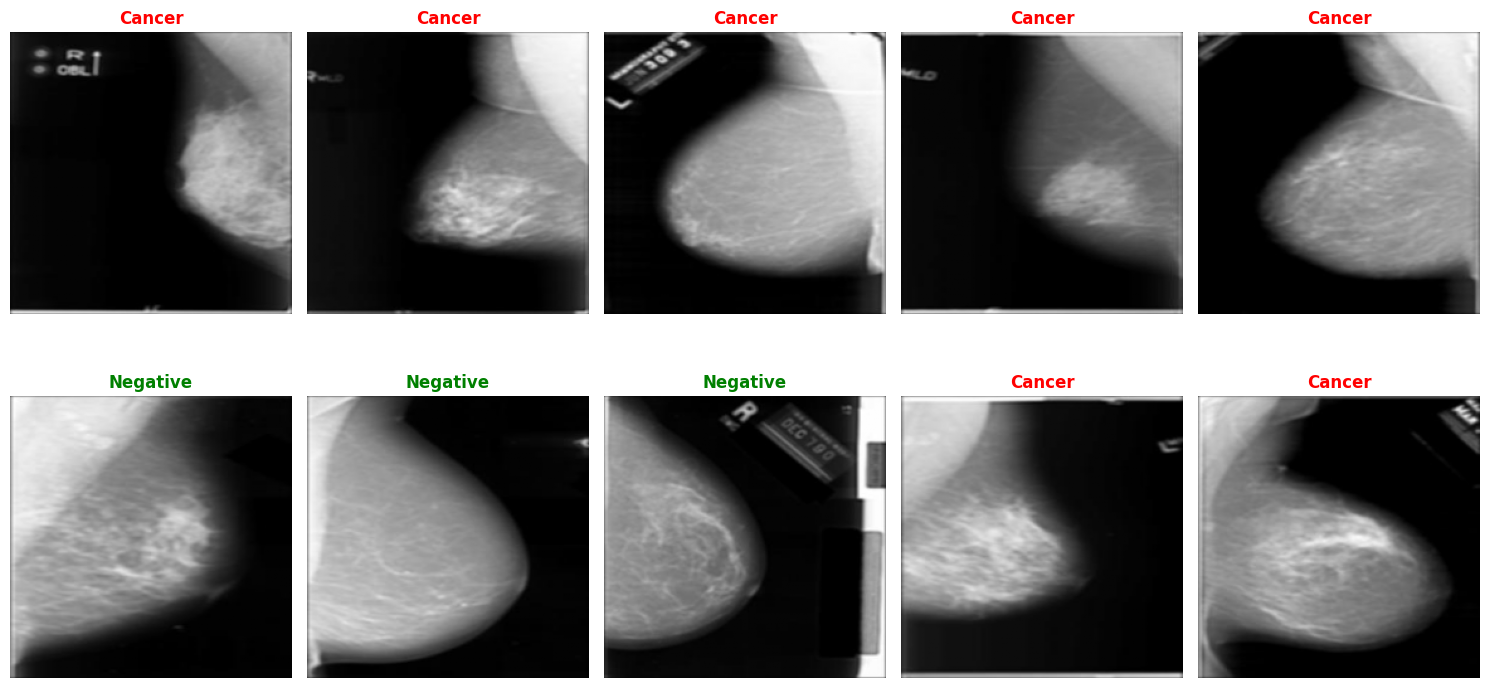

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_random_images(X, y, class_labels, num_images=10):
    """
    Displays random images from the dataset along with their corresponding class labels.
    """
    indices = np.random.choice(len(X), num_images, replace=False)
    
    plt.figure(figsize=(15, 8))
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1) 
        plt.imshow(X[idx])
 
        label_index = int(y[idx])
        class_name = class_labels[label_index] # Convert index to name (Negative/Cancer)
        color = 'green' if label_index == 0 else 'red'
        plt.title(f"{class_name}", color=color, fontsize=12, fontweight='bold')
        plt.axis('off') 

    plt.tight_layout()
    plt.show()

class_names = ['Negative', 'Cancer']

visualize_random_images(X, y, class_names, num_images=10)

# Train/Test Split

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)

(656, 224, 224, 3)
(164, 224, 224, 3)
(656,)


# Data Augmentation

In [10]:
# This generates new training samples by rotating, shifting, and flipping images
data_generation = ImageDataGenerator(
    rotation_range=40,        # Rotate images up to 40 degrees
    width_shift_range=0.2,    # Shift width by 20%
    height_shift_range=0.2,   # Shift height by 20%
    shear_range=0.2,          # Shear intensity
    zoom_range=0.2,           # Zoom in/out
    horizontal_flip=True,     # Flip images horizontally
    fill_mode='nearest'       # Fill pixels after rotation/shift
)

data_generation.fit(X_train)

print("Data Augmentation initialized.")

Data Augmentation initialized.


# Training of CNN Model 

In [11]:
model = Sequential()

# 1st Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D((2, 2)))

# 2nd Convolutional Block
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# 3rd Convolutional Block
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Flattening and Dense Layers
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5)) # Dropout to prevent overfitting

# Output Layer (Sigmoid for binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

c:\Users\kiana\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,396,609 (169.36 MB)

 Trainable params: 44,396,609 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=5,
                           restore_best_weights=True)


history = model.fit(data_generation.flow(X_train, y_train, batch_size=32),
                    validation_data=(X_test, y_test),
                    epochs=50,
                    callbacks=[early_stop])

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6235 - loss: 1.0080 - val_accuracy: 0.6829 - val_loss: 0.6287
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 939ms/step - accuracy: 0.7500 - loss: 0.5122 - val_accuracy: 0.7744 - val_loss: 0.5364
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 910ms/step - accuracy: 0.8018 - loss: 0.4624 - val_accuracy: 0.7744 - val_loss: 0.5598
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 900ms/step - accuracy: 0.8018 - loss: 0.4838 - val_accuracy: 0.7866 - val_loss: 0.5199
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 866ms/step - accuracy: 0.8125 - loss: 0.4426 - val_accuracy: 0.7866 - val_loss: 0.5488
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 879ms/step - accuracy: 0.8186 - loss: 0.4408 - val_accuracy: 0.7744 - val_loss: 0.5402
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 906ms/step - accuracy: 0.8034 - loss: 0.4318 - val_accuracy: 0.7622 - val_loss: 0.5550
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 871ms/step - accuracy: 0.8186 - loss: 0.4154 - val_accurac

# Performance Visualization

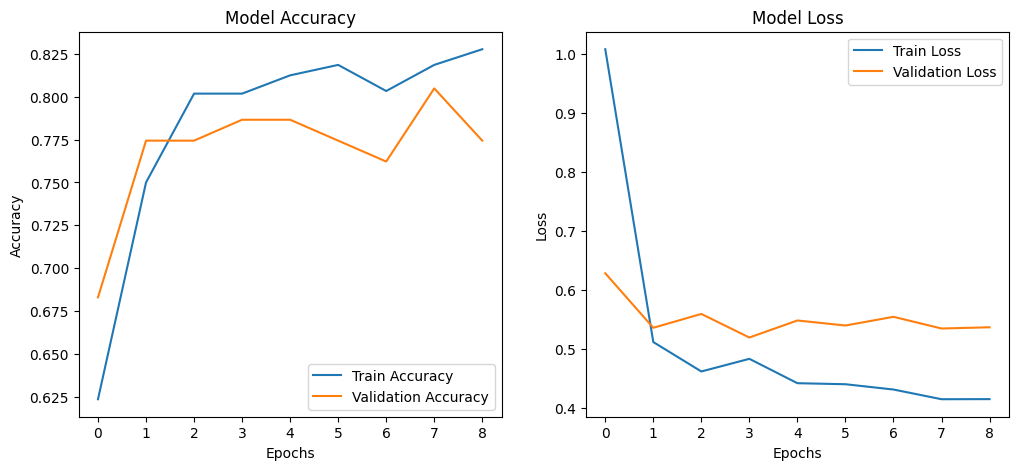

In [ ]:
# Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

# Plot Accuracy~
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluation & Confusion Matrix

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.7866 - loss: 0.5199
Test Accuracy: 78.66%
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step

Classification Report:

              precision    recall  f1-score   support

    Negative       0.72      0.93      0.81        82
      Cancer       0.90      0.65      0.75        82

    accuracy                           0.79       164
   macro avg       0.81      0.79      0.78       164
weighted avg       0.81      0.79      0.78       164



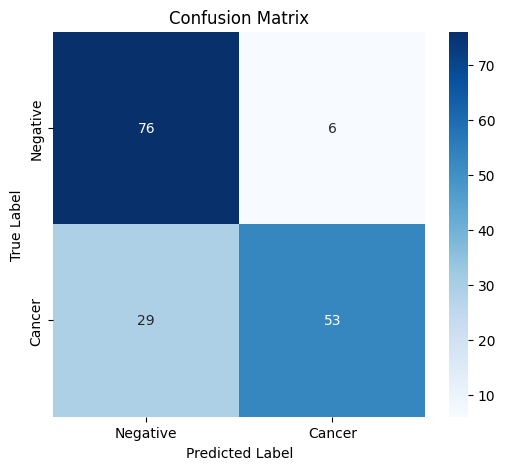

In [14]:
# Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Generate predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=CATEGORIES))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()